# Machine Learning Project by Rizka Alfadilla: [BISINDO0]

## Packages/Library

In [1]:
# Tunggu hingga semua library terinstall baru restart session

!pip install tensorflowjs

INFO: pip is looking at multiple versions of wheel to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 3.8 MB/s eta 0:00:00
  Attempting uninstall: wheel
    Found existing installation: wheel 0.46.3
    Uninstalling wheel-0.46.3:
      Successfully uninstalled wheel-0.46.3
  Attempting uninstall: packaging
    Found existing installation: packaging 26.0
    Uninstalling packaging-26.0:
      Successfully uninstalled packaging-26.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
db-dtypes 1.5.1 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
google-cloud-bigquery 3.41.0 requires pack

In [1]:
# Menonaktifkan warning yang mungkin muncul
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
# Library Umum
import os
import sys
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

In [3]:
# Machine Learning & Model Inference
import tensorflow as tf
import joblib
import tensorflowjs

# Pelatihan dan evaluasi
import seaborn as sns
import sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
# Mencetak versi Library yang sedang digunakan
print(f'Python Version: {sys.version.split()[0]}')
print(f'Pandas Version: {pd.__version__}')
print(f'Numpy Version: {np.__version__}')
print(f'Scikit Learn Version: {sklearn.__version__}')
print(f'Tensorflow Version: {tf.__version__}')
print(f'TensorFlow.js Version: {tensorflowjs.__version__}')

Python Version: 3.12.13
Pandas Version: 2.2.2
Numpy Version: 2.0.2
Scikit Learn Version: 1.6.1
Tensorflow Version: 2.19.0
TensorFlow.js Version: 4.22.0


## Data Preparation

### Data Loading

In [5]:
df = pd.read_csv("bisindo_landmarks_scaled.csv")

df.head(10)

,label,left_0_x,left_0_y,left_0_z,left_1_x,left_1_y,left_1_z,left_2_x,left_2_y,left_2_z,...,right_17_z,right_18_x,right_18_y,right_18_z,right_19_x,right_19_y,right_19_z,right_20_x,right_20_y,right_20_z
0,A,0.0,0.0,0.0,0.156685,-0.005541,-0.047836,0.326597,-0.096635,-0.089321,...,-0.119791,-0.230589,-0.322556,-0.164190,-0.180070,-0.233319,-0.134155,-0.136272,-0.243931,-0.101799
1,A,0.0,0.0,0.0,0.124238,0.051174,-0.111407,0.275913,-0.007208,-0.168738,...,-0.133209,0.029571,-0.489174,-0.208708,0.039503,-0.347661,-0.176480,0.000339,-0.302568,-0.136870
2,A,0.0,0.0,0.0,0.130286,0.051193,-0.105222,0.282595,-0.011618,-0.156156,...,-0.141321,0.024570,-0.490553,-0.219102,0.035941,-0.349902,-0.188352,-0.005280,-0.299756,-0.149545
3,A,0.0,0.0,0.0,0.137191,-0.021136,-0.046313,0.283184,-0.164059,-0.077592,...,-0.114921,-0.093922,-0.406087,-0.152573,-0.081484,-0.300141,-0.121113,-0.047573,-0.310949,-0.087608
4,A,0.0,0.0,0.0,0.137996,-0.021240,-0.059541,0.271545,-0.133857,-0.112326,...,-0.111222,-0.073816,-0.417671,-0.157776,-0.075675,-0.300156,-0.128197,-0.047202,-0.294901,-0.092794
5,A,0.0,0.0,0.0,0.151932,-0.019745,-0.042662,0.305021,-0.173366,-0.063968,...,-0.110696,-0.081948,-0.416063,-0.152996,-0.072827,-0.300603,-0.120237,-0.042862,-0.309815,-0.083606
6,A,0.0,0.0,0.0,0.139368,0.002034,-0.049386,0.302168,-0.114923,-0.084227,...,-0.104203,-0.095019,-0.424014,-0.142334,-0.095506,-0.312353,-0.107755,-0.054285,-0.313334,-0.070810
7,A,0.0,0.0,0.0,0.141550,0.007997,-0.064385,0.300338,-0.083856,-0.108837,...,-0.102220,-0.059582,-0.393889,-0.137699,-0.061197,-0.289031,-0.104952,-0.022213,-0.289919,-0.070336
8,A,0.0,0.0,0.0,0.133834,0.019299,-0.067239,0.289597,-0.050611,-0.117009,...,-0.104265,-0.025817,-0.388874,-0.141514,-0.038556,-0.286191,-0.106735,-0.002832,-0.278959,-0.069590
9,A,0.0,0.0,0.0,0.139147,-0.010298,-0.047088,0.290565,-0.146799,-0.078040,...,-0.107374,-0.105433,-0.429095,-0.137642,-0.102084,-0.316622,-0.100606,-0.059779,-0.317522,-0.065484


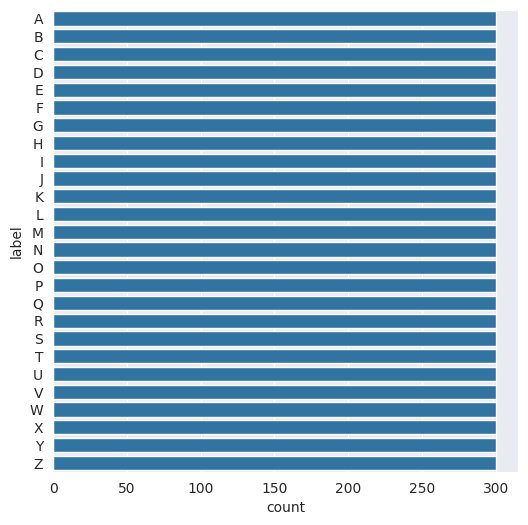

In [6]:
# Plot distribusi gambar di setiap kelas
Label = df['label']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

In [7]:
df['label'].value_counts()

,count
label,
A,300
B,300
C,300
D,300
E,300
F,300
G,300
H,300
I,300


### Data Preprocessing

#### Split Dataset

In [8]:
def split_train_val_test(
    csv_filename,
    train_file,
    val_file,
    test_file,
    train_size=0.70,
    val_size=0.15,
    test_size=0.15,
    random_state=42
):
    # Pastikan total proporsi sama dengan 1
    total_size = train_size + val_size + test_size

    if not abs(total_size - 1.0) < 1e-9:
        raise ValueError(
            "Jumlah train_size, val_size, dan test_size harus sama dengan 1."
        )

    # Memuat dataset
    df = pd.read_csv(csv_filename)

    # Memastikan kolom label tersedia
    if "label" not in df.columns:
        raise ValueError("CSV harus memiliki kolom 'label'.")

    # Memisahkan fitur dan label
    X = df.drop(columns=["label"])
    y = df["label"]

    # Tahap 1:
    # Membagi 70% data pelatihan dan 30% data sementara
    X_train, X_temp, y_train, y_temp = train_test_split(
        X,
        y,
        train_size=train_size,
        stratify=y,
        random_state=random_state,
        shuffle=True
    )

    # Menghitung proporsi test terhadap data sementara
    relative_test_size = test_size / (val_size + test_size)

    # Tahap 2:
    # Membagi data sementara menjadi 15% validasi dan 15% pengujian
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=relative_test_size,
        stratify=y_temp,
        random_state=random_state,
        shuffle=True
    )

    # Menggabungkan kembali label dan fitur
    train_df = pd.concat(
        [
            y_train.reset_index(drop=True),
            X_train.reset_index(drop=True)
        ],
        axis=1
    )

    val_df = pd.concat(
        [
            y_val.reset_index(drop=True),
            X_val.reset_index(drop=True)
        ],
        axis=1
    )

    test_df = pd.concat(
        [
            y_test.reset_index(drop=True),
            X_test.reset_index(drop=True)
        ],
        axis=1
    )

    # Menyimpan masing-masing subset ke file CSV
    train_df.to_csv(train_file, index=False)
    val_df.to_csv(val_file, index=False)
    test_df.to_csv(test_file, index=False)

    # Menampilkan hasil pembagian
    print("Dataset berhasil dibagi:")
    print(
        f"  Train Set      : {train_df.shape[0]} sampel, "
        f"{train_df.shape[1]} kolom"
    )
    print(
        f"  Validation Set : {val_df.shape[0]} sampel, "
        f"{val_df.shape[1]} kolom"
    )
    print(
        f"  Test Set       : {test_df.shape[0]} sampel, "
        f"{test_df.shape[1]} kolom"
    )

    print("\nPersentase aktual:")
    print(f"  Train      : {len(train_df) / len(df) * 100:.2f}%")
    print(f"  Validation : {len(val_df) / len(df) * 100:.2f}%")
    print(f"  Test       : {len(test_df) / len(df) * 100:.2f}%")

    return train_df, val_df, test_df

In [9]:
train_df, val_df, test_df = split_train_val_test(
    csv_filename="bisindo_landmarks_scaled.csv",
    train_file="train.csv",
    val_file="validation.csv",
    test_file="test.csv"
)

Dataset berhasil dibagi:
  Train Set      : 5460 sampel, 127 kolom
  Validation Set : 1170 sampel, 127 kolom
  Test Set       : 1170 sampel, 127 kolom

Persentase aktual:
  Train      : 70.00%
  Validation : 15.00%
  Test       : 15.00%


## Modelling

In [10]:
# Parameter
epochs = 100
batch_size = 32

checkpoint_dir = "./checkpoints"
saved_model_mlp_dir = "./saved_models_mlp"

# Pastikan folder tersedia
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(saved_model_mlp_dir, exist_ok=True)


##### Function: Load Train, Validation, and Test Dataset

def load_dataset(train_file, val_file, test_file):
    # Membaca masing-masing subset
    train_df = pd.read_csv(train_file)
    val_df = pd.read_csv(val_file)
    test_df = pd.read_csv(test_file)

    # Memastikan seluruh file memiliki kolom label
    for file_name, dataframe in {
        "train": train_df,
        "validation": val_df,
        "test": test_df
    }.items():
        if "label" not in dataframe.columns:
            raise ValueError(
                f"File {file_name} harus memiliki kolom 'label'."
            )

    # Kolom yang tidak digunakan sebagai fitur model
    non_feature_columns = ["label", "path", "file_name"]

    def separate_features_and_labels(dataframe):
        drop_columns = [
            column
            for column in non_feature_columns
            if column in dataframe.columns
        ]

        X = dataframe.drop(columns=drop_columns).values.astype("float32")
        y = dataframe["label"].values

        return X, y

    # Memisahkan fitur dan label
    X_train, y_train = separate_features_and_labels(train_df)
    X_val, y_val = separate_features_and_labels(val_df)
    X_test, y_test = separate_features_and_labels(test_df)

    # Memastikan jumlah fitur konsisten
    if not (
        X_train.shape[1]
        == X_val.shape[1]
        == X_test.shape[1]
    ):
        raise ValueError(
            "Jumlah fitur pada train, validation, dan test tidak sama."
        )

    # LabelEncoder hanya di-fit menggunakan data pelatihan
    label_encoder = LabelEncoder()
    y_train = label_encoder.fit_transform(y_train)

    # Memastikan tidak terdapat label baru pada validation dan test
    train_classes = set(label_encoder.classes_)

    unknown_val_labels = set(y_val) - train_classes
    unknown_test_labels = set(y_test) - train_classes

    if unknown_val_labels:
        raise ValueError(
            f"Label pada validation tidak ditemukan di train: "
            f"{unknown_val_labels}"
        )

    if unknown_test_labels:
        raise ValueError(
            f"Label pada test tidak ditemukan di train: "
            f"{unknown_test_labels}"
        )

    # Transformasi label validation dan test
    y_val = label_encoder.transform(y_val)
    y_test = label_encoder.transform(y_test)

    return (
        X_train,
        y_train,
        X_val,
        y_val,
        X_test,
        y_test,
        label_encoder
    )


##### Load Dataset

(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    label_encoder
) = load_dataset(
    train_file="train.csv",
    val_file="validation.csv",
    test_file="test.csv"
)

# Simpan LabelEncoder
joblib.dump(label_encoder, "label_encoder.pkl")

print("Label encoder berhasil dibuat dan disimpan.")

print("\nUkuran fitur:")
print("X_train shape:", X_train.shape)
print("X_val shape  :", X_val.shape)
print("X_test shape :", X_test.shape)

print("\nUkuran label:")
print("y_train shape:", y_train.shape)
print("y_val shape  :", y_val.shape)
print("y_test shape :", y_test.shape)

# Jumlah fitur dan kelas ditentukan dari dataset
input_dim = X_train.shape[1]
num_classes = len(label_encoder.classes_)

print("\nJumlah fitur:", input_dim)
print("Jumlah kelas:", num_classes)
print("Daftar kelas:", label_encoder.classes_)

# Validasi jumlah fitur landmark
expected_input_dim = 126

if input_dim != expected_input_dim:
    raise ValueError(
        f"Jumlah fitur ditemukan {input_dim}, "
        f"sedangkan yang diharapkan {expected_input_dim}."
    )

Label encoder berhasil dibuat dan disimpan.

Ukuran fitur:
X_train shape: (5460, 126)
X_val shape  : (1170, 126)
X_test shape : (1170, 126)

Ukuran label:
y_train shape: (5460,)
y_val shape  : (1170,)
y_test shape : (1170,)

Jumlah fitur: 126
Jumlah kelas: 26
Daftar kelas: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']


In [11]:
# --- Multilayer Perceptron Model ---
def create_mlp_model(input_dim, num_classes):
    model = tf.keras.models.Sequential(
        [
            tf.keras.layers.Input(
                shape=(input_dim,),
                name="input_landmark"
            ),

            tf.keras.layers.Dense(
                128,
                activation="relu",
                name="hidden_layer_1"
            ),

            tf.keras.layers.Dropout(
                0.25,
                name="dropout_1"
            ),

            tf.keras.layers.Dense(
                64,
                activation="relu",
                name="hidden_layer_2"
            ),

            tf.keras.layers.Dropout(
                0.20,
                name="dropout_2"
            ),

            tf.keras.layers.Dense(
                num_classes,
                activation="softmax",
                name="output_layer"
            )
        ],
        name="MLP_BISINDO"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [12]:
# --- Callback MLP ---
mlp_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(
            checkpoint_dir,
            "best_model_mlp.h5"
        ),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),

    tf.keras.callbacks.TensorBoard(
        log_dir="./logs/mlp"
    )
]

In [13]:
# --- Training MLP ---
mlp_model = create_mlp_model(
    input_dim=input_dim,
    num_classes=num_classes
)

print("\nTraining Multilayer Perceptron (MLP)...")

mlp_history = mlp_model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    callbacks=mlp_callbacks,
    verbose=1,
    shuffle=True
)


Training Multilayer Perceptron (MLP)...
Epoch 1/100
166/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2447 - loss: 2.6640
Epoch 1: val_loss improved from None to 0.98008, saving model to ./checkpoints/best_model_mlp.h5



Epoch 1: finished saving model to ./checkpoints/best_model_mlp.h5
171/171 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3879 - loss: 2.0773 - val_accuracy: 0.7641 - val_loss: 0.9801 - learning_rate: 0.0010
Epoch 2/100
150/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6422 - loss: 1.0729
Epoch 2: val_loss improved from 0.98008 to 0.44444, saving model to ./checkpoints/best_model_mlp.h5



Epoch 2: finished saving model to ./checkpoints/best_model_mlp.h5
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7042 - loss: 0.8996 - val_accuracy: 0.8863 - val_loss: 0.4444 - learning_rate: 0.0010
Epoch 3/100
157/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8023 - loss: 0.6024
Epoch 3: val_loss improved from 0.44444 to 0.30722, saving model to ./checkpoints/best_model_mlp.h5



Epoch 3: finished saving model to ./checkpoints/best_model_mlp.h5
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8212 - loss: 0.5450 - val_accuracy: 0.9111 - val_loss: 0.3072 - learning_rate: 0.0010
Epoch 4/100
164/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8638 - loss: 0.4074
Epoch 4: val_loss improved from 0.30722 to 0.20842, saving model to ./checkpoints/best_model_mlp.h5



Epoch 4: finished saving model to ./checkpoints/best_model_mlp.h5
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8727 - loss: 0.3935 - val_accuracy: 0.9624 - val_loss: 0.2084 - learning_rate: 0.0010
Epoch 5/100
167/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8949 - loss: 0.3215
Epoch 5: val_loss improved from 0.20842 to 0.17113, saving model to ./checkpoints/best_model_mlp.h5


...


Epoch 24: finished saving model to ./checkpoints/best_model_mlp.h5
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9899 - loss: 0.0403 - val_accuracy: 0.9897 - val_loss: 0.0358 - learning_rate: 0.0010
Epoch 25/100
170/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9863 - loss: 0.0477
Epoch 25: val_loss did not improve from 0.03581
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9864 - loss: 0.0461 - val_accuracy: 0.9872 - val_loss: 0.0413 - learning_rate: 0.0010
Epoch 26/100
169/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9892 - loss: 0.0377
Epoch 26: val_loss did not improve from 0.03581
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9899 - loss: 0.0377 - val_accuracy: 0.9889 - val_loss: 0.0372 - learning_rate: 0.0010
Epoch 27/100
164/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9912 - loss: 0.0321
Epoch 27: val_loss improved from 0.03581 to 0.03490, saving model to ./checkpoints/best_model_mlp.h5



Epoch 27: finished saving model to ./checkpoints/best_model_mlp.h5
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9899 - loss: 0.0377 - val_accuracy: 0.9915 - val_loss: 0.0349 - learning_rate: 0.0010
Epoch 28/100
158/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9903 - loss: 0.0325
Epoch 28: val_loss did not improve from 0.03490
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9886 - loss: 0.0381 - val_accuracy: 0.9889 - val_loss: 0.0359 - learning_rate: 0.0010
Epoch 29/100
166/171 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9874 - loss: 0.0450
Epoch 29: val_loss did not improve from 0.03490
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9890 - loss: 0.0403 - val_accuracy: 0.9880 - val_loss: 0.0371 - learning_rate: 0.0010
Epoch 30/100
154/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9905 - loss: 0.0338
Epoch 30: val_loss did not improve from 0.03490
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9907 - loss: 0.0346 - val_accuracy: 0.9889 - v


Epoch 35: finished saving model to ./checkpoints/best_model_mlp.h5
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9940 - loss: 0.0249 - val_accuracy: 0.9915 - val_loss: 0.0340 - learning_rate: 5.0000e-04
Epoch 36/100
160/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9927 - loss: 0.0230
Epoch 36: val_loss improved from 0.03404 to 0.03300, saving model to ./checkpoints/best_model_mlp.h5



Epoch 36: finished saving model to ./checkpoints/best_model_mlp.h5
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9934 - loss: 0.0224 - val_accuracy: 0.9889 - val_loss: 0.0330 - learning_rate: 5.0000e-04
Epoch 37/100
165/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9932 - loss: 0.0288
Epoch 37: val_loss improved from 0.03300 to 0.02769, saving model to ./checkpoints/best_model_mlp.h5



Epoch 37: finished saving model to ./checkpoints/best_model_mlp.h5
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9930 - loss: 0.0268 - val_accuracy: 0.9915 - val_loss: 0.0277 - learning_rate: 5.0000e-04
Epoch 38/100
164/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9932 - loss: 0.0253
Epoch 38: val_loss did not improve from 0.02769
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9940 - loss: 0.0250 - val_accuracy: 0.9880 - val_loss: 0.0300 - learning_rate: 5.0000e-04
Epoch 39/100
155/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9947 - loss: 0.0197
Epoch 39: val_loss did not improve from 0.02769
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9938 - loss: 0.0220 - val_accuracy: 0.9915 - val_loss: 0.0352 - learning_rate: 5.0000e-04
Epoch 40/100
165/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9958 - loss: 0.0216
Epoch 40: val_loss did not improve from 0.02769
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9947 - loss: 0.0233 - val_accuracy

## Evaluation and Visualization

In [14]:
print("\nEvaluating MLP Model:")

# Memuat model terbaik hasil ModelCheckpoint
best_model_path = os.path.join(
    checkpoint_dir,
    "best_model_mlp.h5"
)

best_mlp_model = tf.keras.models.load_model(
    best_model_path
)

# Evaluasi pada data training
mlp_train_loss, mlp_train_acc = best_mlp_model.evaluate(
    X_train,
    y_train,
    verbose=0
)

# Evaluasi pada data validation
mlp_val_loss, mlp_val_acc = best_mlp_model.evaluate(
    X_val,
    y_val,
    verbose=0
)

# Evaluasi akhir pada data testing
mlp_test_loss, mlp_test_acc = best_mlp_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Train Loss       : {mlp_train_loss:.4f}")
print(f"Train Accuracy   : {mlp_train_acc:.4f}")

print(f"Validation Loss  : {mlp_val_loss:.4f}")
print(f"Validation Acc.  : {mlp_val_acc:.4f}")

print(f"Test Loss        : {mlp_test_loss:.4f}")
print(f"Test Accuracy    : {mlp_test_acc:.4f}")


# Prediksi pada data pengujian
y_pred_probability = best_mlp_model.predict(
    X_test,
    verbose=0
)

y_pred_mlp = np.argmax(
    y_pred_probability,
    axis=1
)


# Classification Report
print("\nClassification Report (MLP):")

print(
    classification_report(
        y_test,
        y_pred_mlp,
        target_names=label_encoder.classes_,
        digits=4,
        zero_division=0
    )
)


Evaluating MLP Model:


Train Loss       : 0.0072
Train Accuracy   : 0.9973
Validation Loss  : 0.0277
Validation Acc.  : 0.9915
Test Loss        : 0.0531
Test Accuracy    : 0.9932

Classification Report (MLP):
              precision    recall  f1-score   support

           A     0.9783    1.0000    0.9890        45
           B     1.0000    1.0000    1.0000        45
           C     0.9574    1.0000    0.9783        45
           D     0.9783    1.0000    0.9890        45
           E     1.0000    1.0000    1.0000        45
           F     1.0000    0.9778    0.9888        45
           G     1.0000    1.0000    1.0000        45
           H     1.0000    1.0000    1.0000        45
           I     1.0000    1.0000    1.0000        45
           J     1.0000    1.0000    1.0000        45
           K     1.0000    1.0000    1.0000        45
           L     1.0000    0.9556    0.9773        45
           M     0.9362    0.9778    0.9565        45
           N     0.9767    0.9333    0.9545        45
   

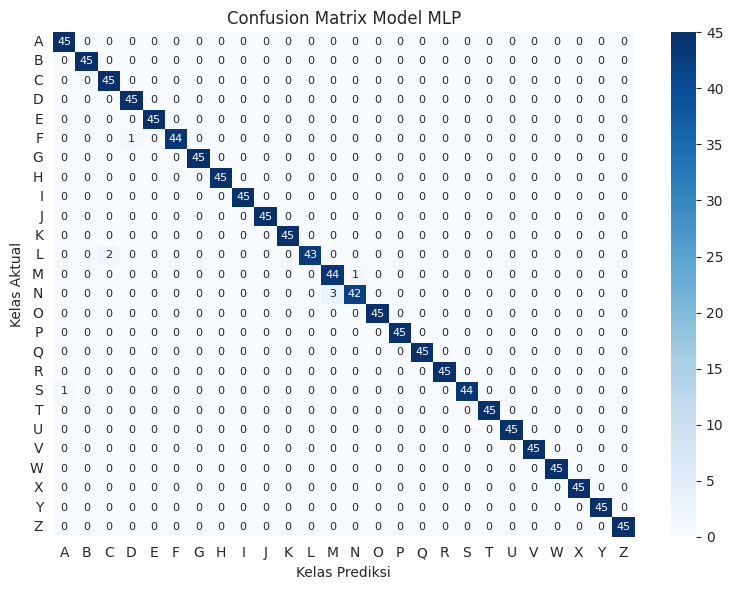

In [22]:
# --- Confusion Matrix (MLP) ---
cm_mlp = confusion_matrix(
    y_test,
    y_pred_mlp
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_mlp,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    annot_kws={"size": 8}
)

plt.title("Confusion Matrix Model MLP")
plt.xlabel("Kelas Prediksi")
plt.ylabel("Kelas Aktual")

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()

# Menyimpan gambar untuk dokumentasi skripsi
plt.savefig(
    "confusion_matrix_mlp.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

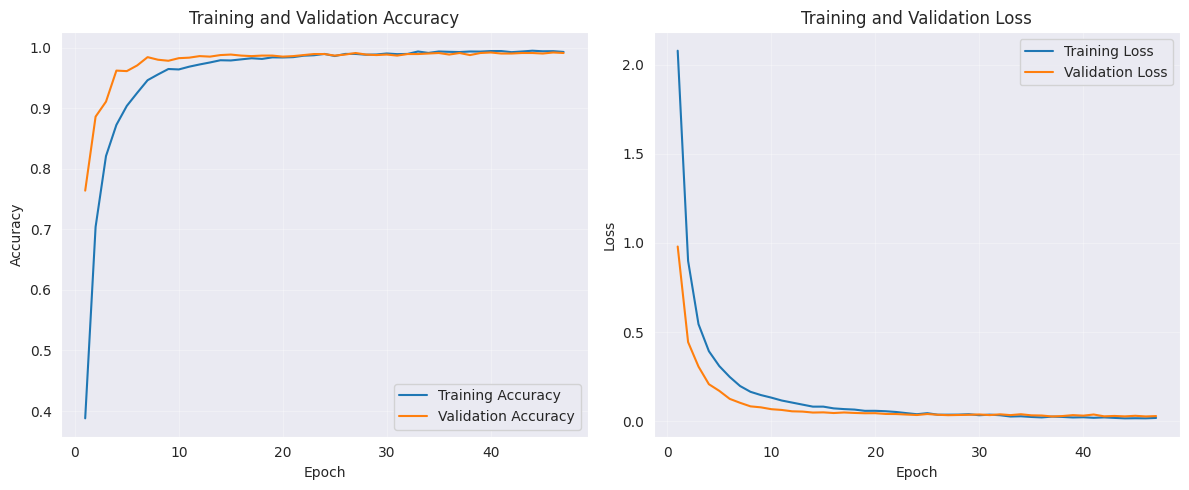

In [16]:
# --- Plot Akurasi dan Loss MLP ---

acc = mlp_history.history["accuracy"]
val_acc = mlp_history.history["val_accuracy"]
loss = mlp_history.history["loss"]
val_loss = mlp_history.history["val_loss"]

# Nomor epoch dimulai dari 1
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Grafik akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

# Grafik loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "training_validation_mlp.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Model Conversion

### SavedModel (TensorFlow)

In [17]:
# --- Export Model Terbaik ke SavedModel ---
best_mlp_model.export(saved_model_mlp_dir)

print(
    f"Model terbaik berhasil diekspor ke: "
    f"{saved_model_mlp_dir}"
)

Saved artifact at './saved_models_mlp'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 126), dtype=tf.float32, name='input_landmark')
Output Type:
  TensorSpec(shape=(None, 26), dtype=tf.float32, name=None)
Captures:
  136033555741968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136033555738320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136033555741008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136033555739856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136033555741392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136033494696208: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model terbaik berhasil diekspor ke: ./saved_models_mlp


In [18]:
# --- Kompres SavedModel menjadi ZIP ---
zip_path = shutil.make_archive(
    base_name="best_model_mlp_savedmodel",
    format="zip",
    root_dir=saved_model_mlp_dir
)

print("File ZIP berhasil dibuat:", zip_path)

# --- Download file ZIP dari Google Colab ---
from google.colab import files

files.download(zip_path)

File ZIP berhasil dibuat: /content/best_model_mlp_savedmodel.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### TensorFlow.js (TFJS)

In [19]:
!tensorflowjs_converter \
    --input_format=tf_saved_model \
    /content/saved_models_mlp/ \
    /content/mlp_tfjs_model

2026-07-30 08:02:35.852415: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1785398555.866276    1615 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785398555.870069    1615 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1785398555.880235    1615 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1785398555.880267    1615 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1785398555.880271    1615 computation_placer.cc:177] computation placer alr

In [20]:
# --- Kompres model TensorFlow.js menjadi ZIP ---
zip_path = shutil.make_archive(
    base_name="mlp_tfjs_model",
    format="zip",
    root_dir=".",
    base_dir="mlp_tfjs_model"
)

print("File ZIP berhasil dibuat:", zip_path)

# Mengunduh file ZIP
files.download(zip_path)

File ZIP berhasil dibuat: /content/mlp_tfjs_model.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
!pip freeze > requirements.txt